In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [ ]:
from sklearn.datasets import make_blobs

x,y = make_blobs(n_samples=1000, centers=3, n_features=2)
x
#not using y

array([[ 1.30207836, -0.88816638],
       [ 1.49198217, -2.21499786],
       [-7.28230531, -2.58746816],
       ...,
       [ 0.55567288,  2.55694737],
       [-1.05916011,  3.31275368],
       [ 1.86538248,  0.69618798]])

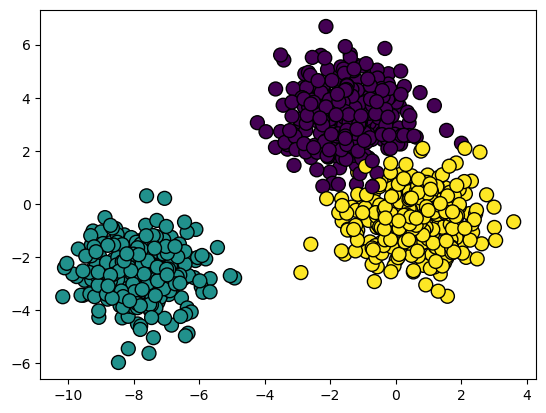

In [6]:
plt.scatter(x[:,0], x[:,1], c=y, marker='o', edgecolor='black', s=100)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,_,_ = train_test_split(x,y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
from sklearn.cluster import KMeans

#Selecting k
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

print(min(wcss))


65.72840836818307


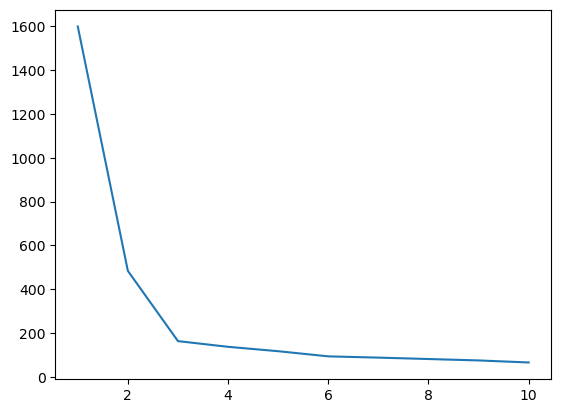

In [12]:
plt.plot(range(1,11), wcss)
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(x_train)
y_kmeans = kmeans.predict(x_test)
y_kmeans

array([0, 2, 0, 1, 1, 0, 2, 2, 1, 1, 0, 1, 1, 1, 1, 1, 2, 0, 2, 0, 2, 0,
       1, 0, 0, 0, 0, 2, 1, 0, 1, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0, 1, 0, 1,
       1, 0, 1, 1, 2, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 0,
       1, 0, 1, 2, 1, 0, 0, 1, 0, 2, 1, 0, 2, 0, 0, 1, 0, 2, 1, 1, 2, 0,
       1, 2, 1, 1, 0, 0, 2, 2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 1, 1, 1, 0, 0,
       0, 2, 0, 0, 2, 2, 2, 0, 1, 1, 2, 1, 0, 2, 2, 1, 2, 0, 0, 2, 1, 2,
       0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 1, 2, 2, 0, 2, 2, 2,
       2, 0, 1, 1, 2, 0, 2, 0, 1, 2, 2, 2, 0, 1, 2, 0, 1, 1, 0, 2, 0, 2,
       2, 0, 0, 1, 1, 0, 0, 2, 1, 2, 1, 1, 0, 2, 0, 1, 2, 0, 0, 1, 1, 2,
       1, 1])

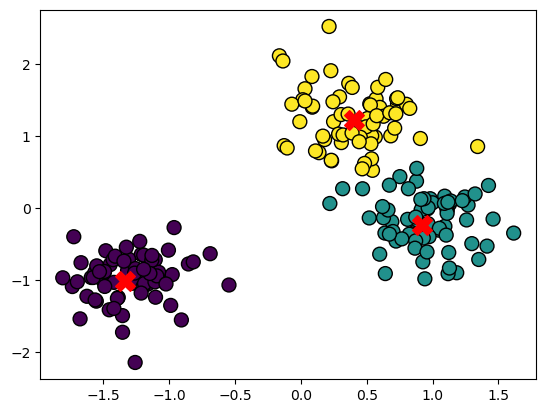

In [14]:
plt.scatter(x_test[:,0], x_test[:,1], c=y_kmeans, marker='o', edgecolor='black', s=100)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X', s=200)
plt.show()

In [15]:
!pip install kneed
from kneed import KneeLocator
k = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
k.elbow

3

In [16]:
from sklearn.metrics import silhouette_score
sil = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_train)
    y_kmeans = kmeans.predict(x_train)
    sil.append(silhouette_score(x_train, y_kmeans))

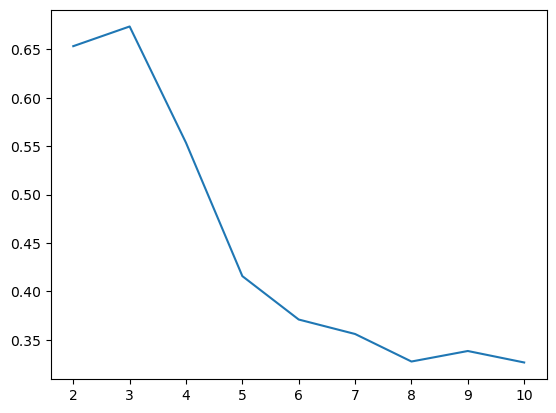

In [17]:
plt.plot(range(2,11), sil)
plt.show()